# This is the part of the homework about NN and PINN

Lotka-Volterra predator-prey model:

\begin{align}

&\frac{dx}{dt} = \alpha x - \beta xy, \\

&\frac{dy}{dt} = \delta xy - \gamma y,

\end{align}

where $x$ - population of hare (in thousands), $y$ - population of lynx (in thousands), and $\alpha, \beta, \gamma, \delta > 0$.

\begin{align}

&\alpha = 0.6, \beta = 0.025, \delta = 0.0125, \gamma = 0.5 \\

& x(0) = 30, y(0) = 4

\end{align}


System simulated for $t = 0,1,...,90$.

# Generating Synthethic Data

In [1]:
import numpy as np
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt 
import torch as tc
import torch.nn as nn

In [2]:
#Check for using GPU on MacOS (No CUDA for MacOS)
print(tc.backends.mps.is_available())
device = tc.device("mps" if tc.backends.mps.is_available() else "cpu")

#For using CUDA, e.g., on Symmetry, comment the above and run the below instead
#device = 'cuda' if tc.cuda.is_available() else 'cpu'

True


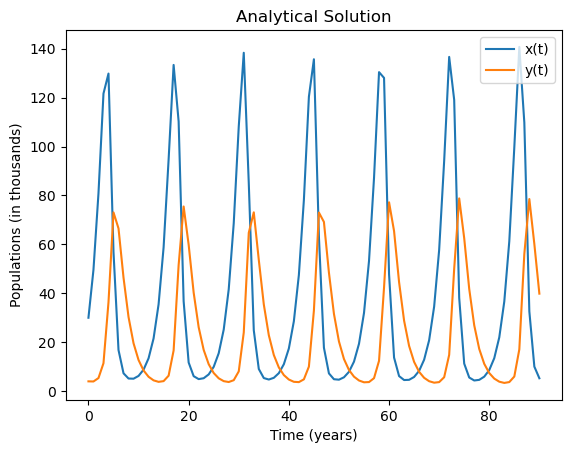

In [3]:
#Solving the system of differential equations

#Parameters
a = 0.6
b = 0.025
d = 0.0125
g = 0.5

#Initail conditions
x0 = 30
y0 = 4

#Time points to evaluate
t_eval = np.linspace(0, 90, 91)
t_span = (0,90)

#Define system of first order differential equations
def populations_ODEs(t, v):
    """
    t - time array 
    v = (x,y) - vector of x and y values
    """
    x, y = v

    dxdt = a*x - b*x*y
    dydt = d*x*y - g*y

    return np.array([dxdt, dydt], dtype=float)

#Solving
sol = solve_ivp(populations_ODEs, t_span, [x0, y0], t_eval=t_eval)



#Accesing the data for plot 
x_data = sol.y[0]
y_data = sol.y[1]


# Plot
fig, ax = plt.subplots()
ax.plot(t_eval, x_data, label="x(t)")
ax.plot(t_eval, y_data, label="y(t)")

ax.set_title("Analytical Solution")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Populations (in thousands)")
ax.legend()

fig.savefig("analytical_solution.png")
plt.show()

In [4]:
#Accessing the synthethic data

t_syn=tc.from_numpy(sol.t).unsqueeze(1).float()
x_syn=tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y_syn=tc.from_numpy(sol.y[1]).unsqueeze(1).float()

In [6]:
#Time based split of the data into training and test set
def split(t, x, y, split_ratio=0.7):
    n = int(len(t) * split_ratio)
    return (t[:n], x[:n], y[:n], t[n:], x[n:], y[n:])

#Train/test split
tS_tr, xS_tr, yS_tr, tS_te, xS_te, yS_te = split(t_syn, x_syn, y_syn)

#Separate evaluation 
test_syn = (tS_te, tc.cat([xS_te, yS_te], dim=1))

# NN POPULATION MODEL

In [7]:
#Defining the model in analogous way to code from tutorial 3

class PopNet(nn.Module):
    def __init__(self, neurons, M, output=2, activation=nn.Tanh()):
        """
        neurons: number of neurons per hidden layer
        M: number of hidden layers
        output: 2 (hare, lynx)
        activation: activation function
        """
        super(PopNet, self).__init__()

        self.neurons = neurons
        self.M = M
        self.output = output

        # Hidden layers
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(1, neurons)]
        )
        self.hidden_layers.extend(
            [nn.Linear(neurons, neurons) for _ in range(M - 1)]
        )

        # Output layer
        self.output_layer = nn.Linear(neurons, output)

        # Activation
        self.activation = activation

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)
        return x

In [34]:
def plot_result(t_syn,x_syn,y_syn,pred_x,pred_y,tS_tr, xS_tr,yS_tr,epoch):
    "Pretty plot training results"

    plt.figure(figsize=(8,4))
    
    plt.plot(t_syn, x_syn, color="grey", linewidth=2, alpha=0.8, label="Data Hare")
    plt.plot(t_syn, y_syn, color="black", linewidth=2, alpha=0.8, label="Data Lynx")

    plt.plot(t_syn, pred_x, color="tab:blue", linewidth=4, alpha=0.8, label="NN Hare pred")
    plt.plot(t_syn, pred_y, color="tab:green", linewidth=4, alpha=0.8, label="NN Lynx pred")

    plt.scatter(tS_tr, xS_tr, s=60, color="tab:orange", alpha=0.4, label='Training Hare data')
    plt.scatter(tS_tr, yS_tr, s=60, color="tab:red", alpha=0.4, label='Training Lynx data')
   
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.title(f"Epoch: {epoch}")
    plt.xlabel("Year")
    plt.ylabel("Population")
    plt.axis()
    plt.show()

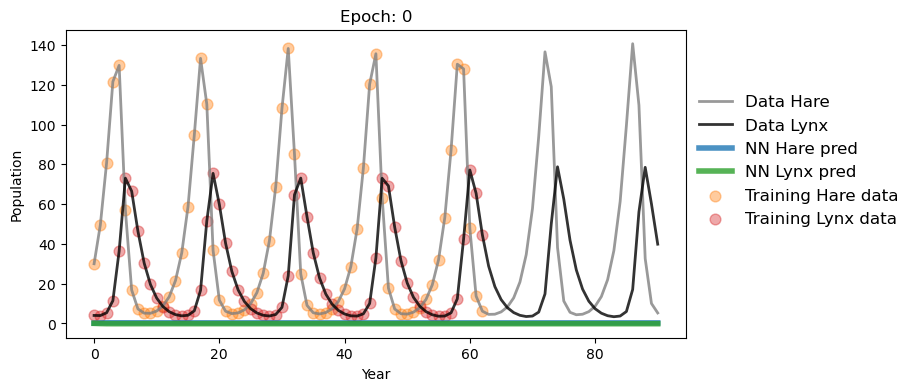

Epoch 0, Loss: 2434.2773


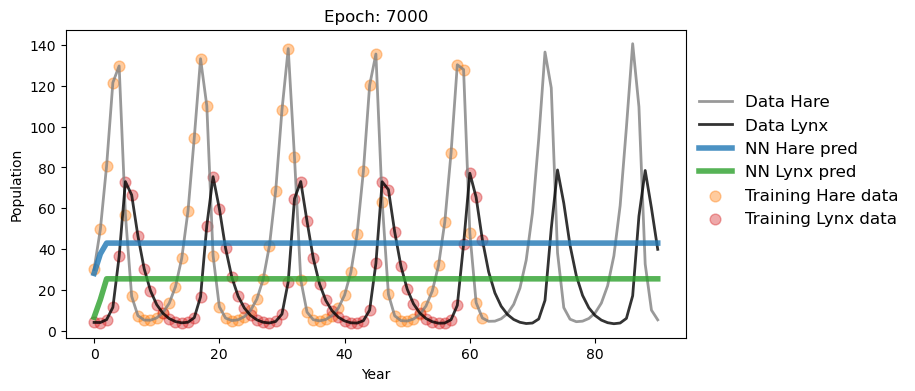

Epoch 7000, Loss: 1214.2307


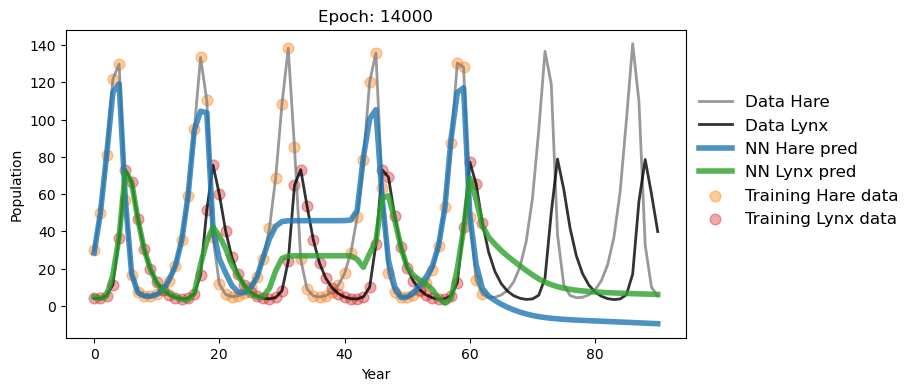

Epoch 14000, Loss: 310.8669


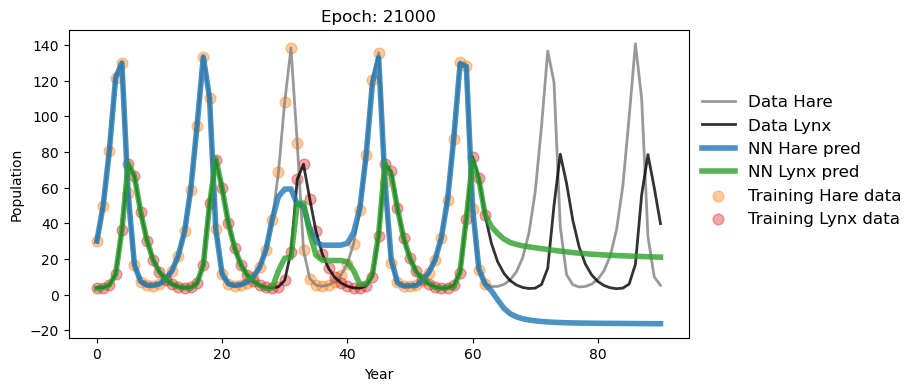

Epoch 21000, Loss: 126.4544


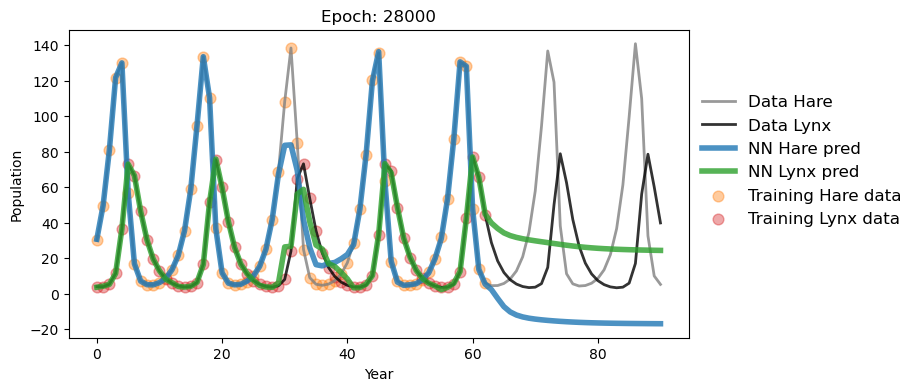

Epoch 28000, Loss: 47.0827


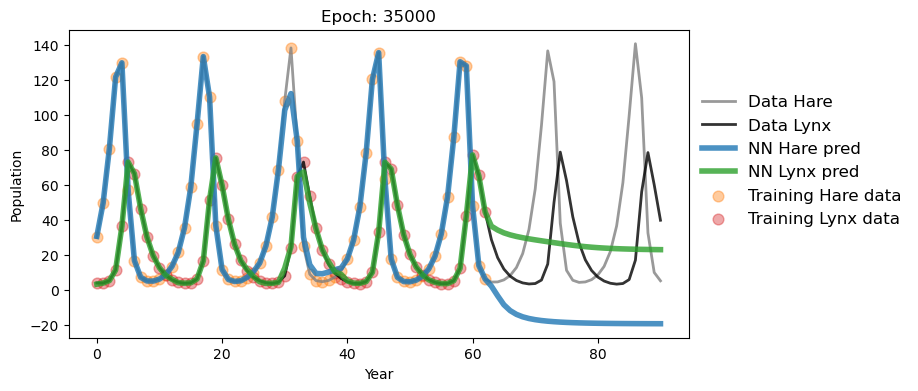

Epoch 35000, Loss: 7.3683


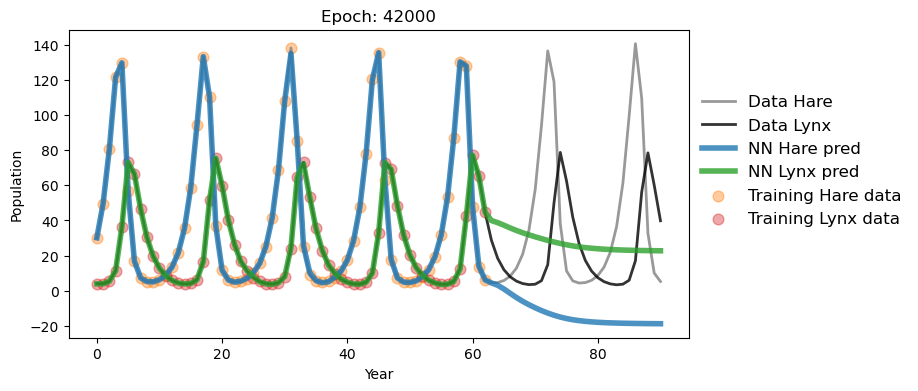

Epoch 42000, Loss: 0.1219


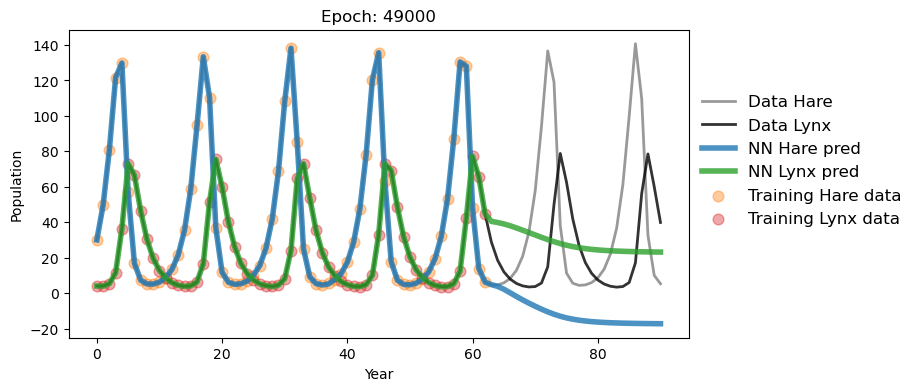

Epoch 49000, Loss: 0.0039


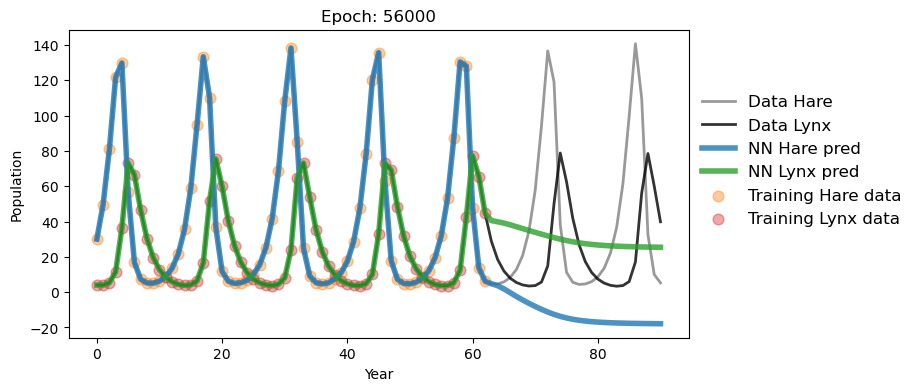

Epoch 56000, Loss: 0.0021


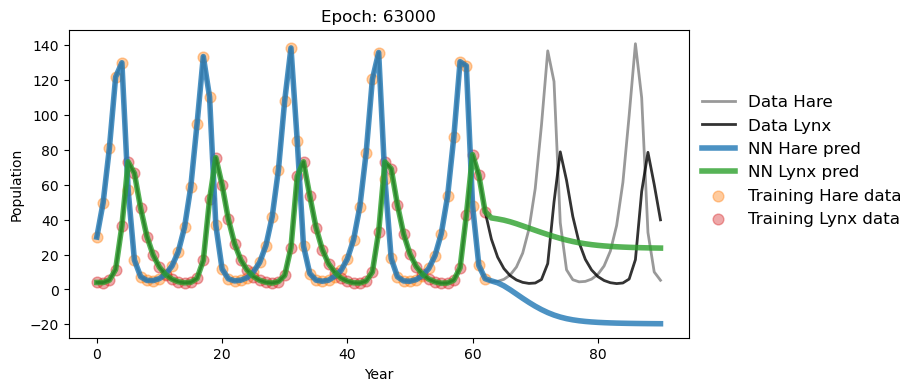

Epoch 63000, Loss: 0.0016


In [37]:
#Training the model 

model = PopNet(neurons=64,M=4,activation=nn.Tanh())
criterion = nn.MSELoss()
optimizer = tc.optim.Adam(model.parameters(), lr=3*1e-4)

epochs = 70000

for epoch in range(epochs):
    model.train()

    pred = model(tS_tr)
    loss = criterion(pred, tc.cat([xS_tr, yS_tr], dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 7000 == 0:
        testing = model(t_syn)
        pred_x = testing[:,0]
        pred_y = testing[:,1]
        plot_result(t_syn,x_syn,y_syn,pred_x.detach(),pred_y.detach(),tS_tr, xS_tr,yS_tr, epoch)
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# NN FOR HISTORICAL DATA SETS

In [38]:
import pandas as pd

In [39]:
#Loading the data

data_set1 = pd.read_csv("Leigh1968_harelynx.csv")

data_set2 = pd.read_csv("lotvol.csv")

## DATA SET 1

In [49]:
#Importing the data
t_real_1 = tc.tensor(data_set1["year"].values, dtype=tc.float32).view(-1, 1)
x_real_1 = tc.tensor(data_set1["hare"].values, dtype=tc.float32).view(-1, 1)
y_real_1= tc.tensor(data_set1["lynx"].values, dtype=tc.float32).view(-1, 1)

#Normalization

t_real_1 = (t_real_1 - t_real_1.min())/(t_real_1.max()- t_real_1.min())
x_real_1 = (x_real_1 - x_real_1.min())/(x_real_1.max()- x_real_1.min())
y_real_1 = (y_real_1 - y_real_1.min())/(y_real_1.max()- y_real_1.min())

#Splitting the data
tR1_tr, xR1_tr, yR1_tr, tR1_te, xR1_te, yR1_te = split(t_real_1, x_real_1, y_real_1)



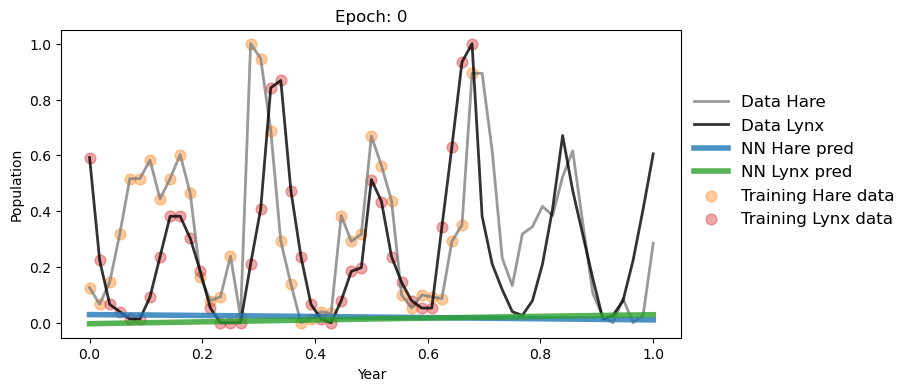

Epoch 0, Loss: 0.2039


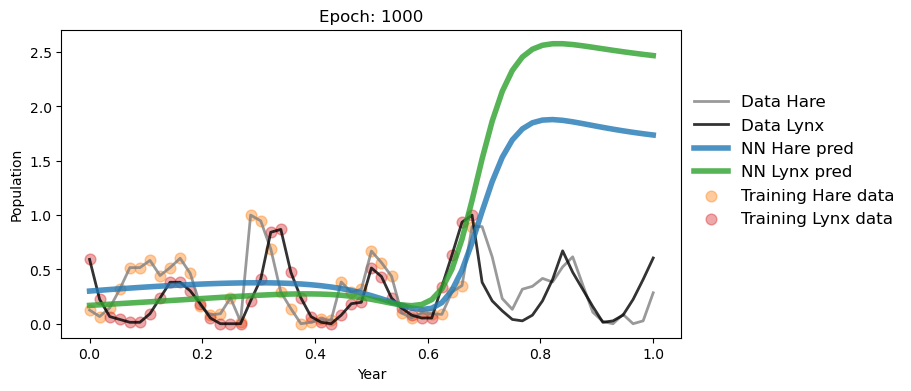

Epoch 1000, Loss: 0.0542


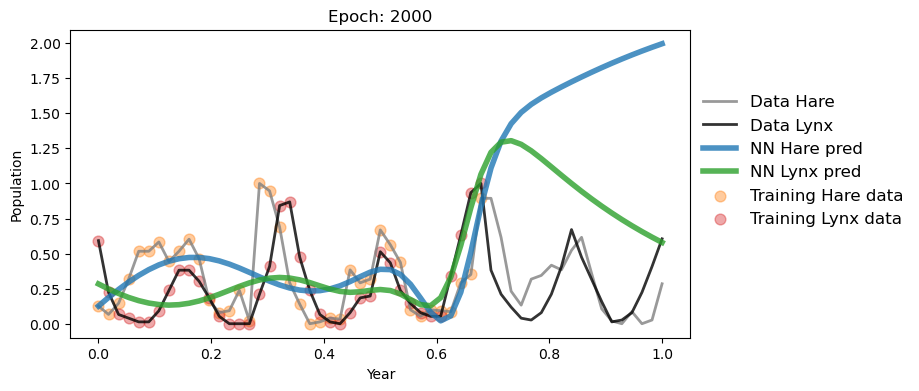

Epoch 2000, Loss: 0.0458


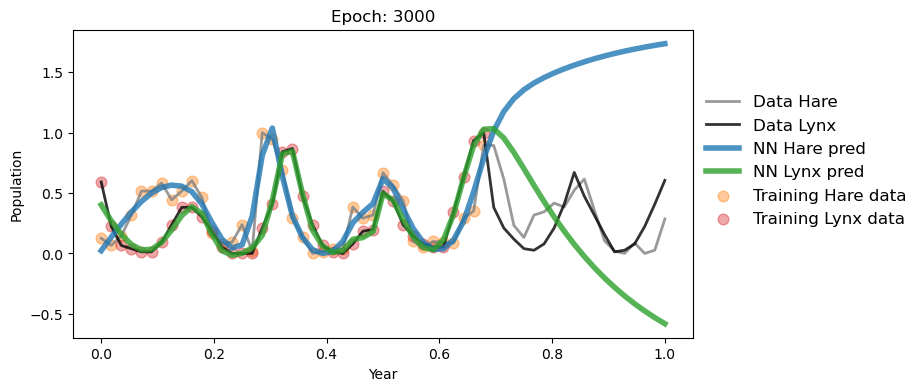

Epoch 3000, Loss: 0.0053


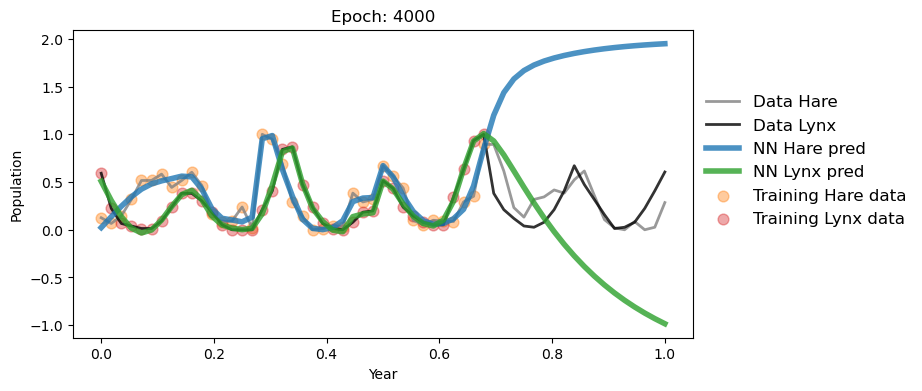

Epoch 4000, Loss: 0.0027


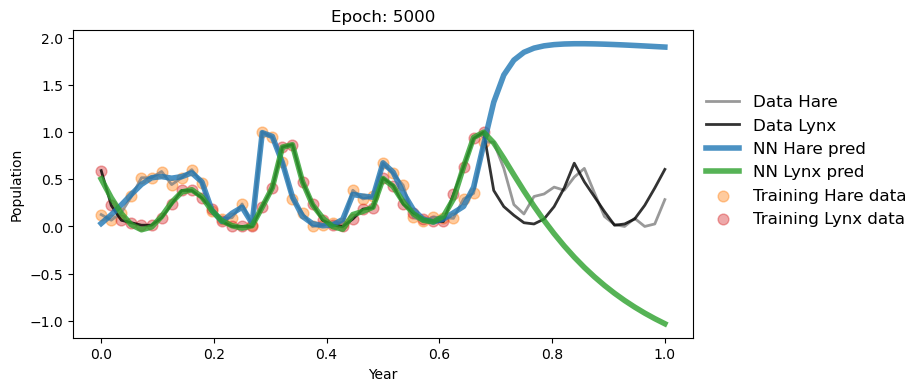

Epoch 5000, Loss: 0.0014


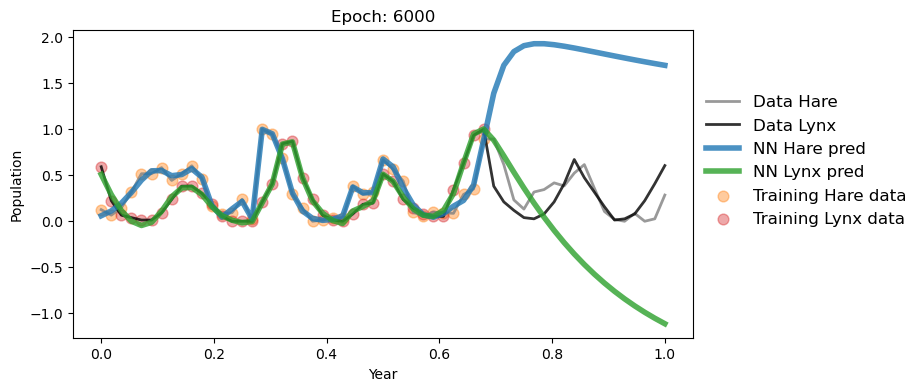

Epoch 6000, Loss: 0.0011


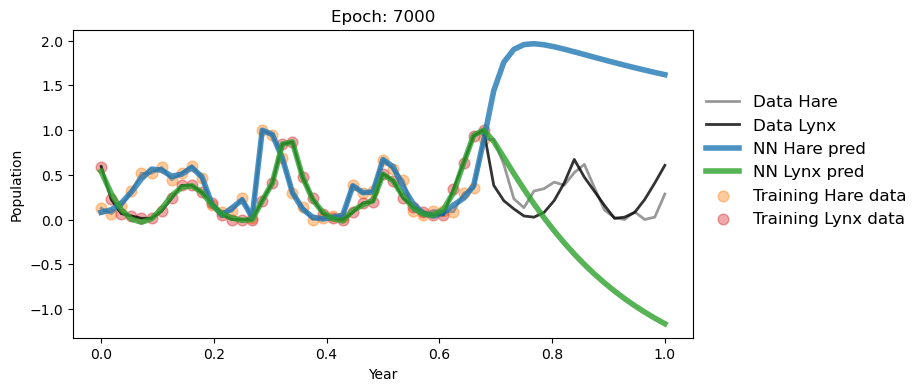

Epoch 7000, Loss: 0.0009


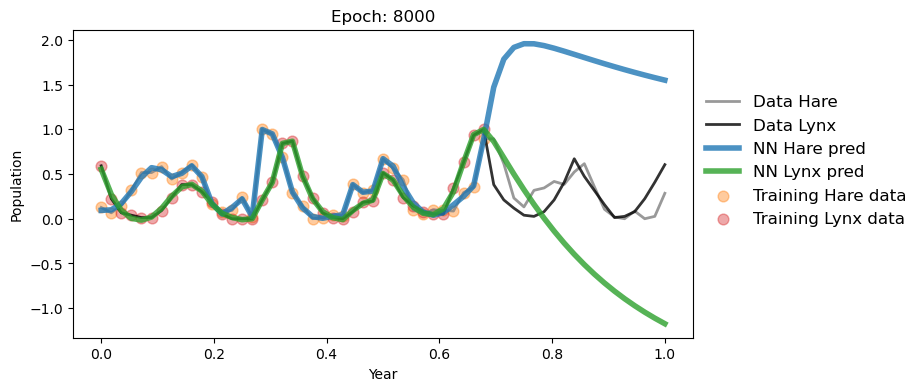

Epoch 8000, Loss: 0.0007


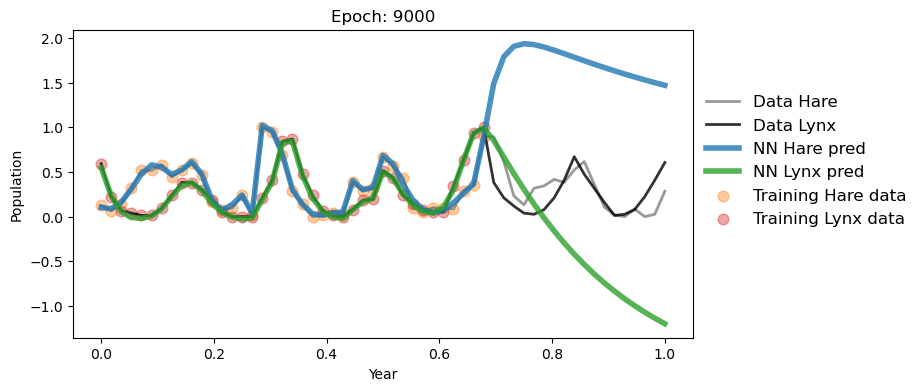

Epoch 9000, Loss: 0.0007


In [52]:
#Training the model for data set 1

model = PopNet(neurons=64,M=4,activation=nn.Tanh())
criterion = nn.MSELoss()
optimizer = tc.optim.Adam(model.parameters(), lr=1*1e-3)

epochs = 10000

for epoch in range(epochs):
    model.train()

    pred = model(tR1_tr)
    loss = criterion(pred, tc.cat([xR1_tr, yR1_tr], dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        testing = model(t_real_1)
        pred_x = testing[:,0]
        pred_y = testing[:,1]
        plot_result(t_real_1 ,x_real_1 ,y_real_1 ,pred_x.detach(),pred_y.detach(),tR1_tr, xR1_tr,yR1_tr, epoch)
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

## DATA SET 2

In [53]:
#Importing the data
t_real_2 = tc.tensor(data_set2["year"].values, dtype=tc.float32).view(-1, 1)
x_real_2 = tc.tensor(data_set2["hare"].values, dtype=tc.float32).view(-1, 1)
y_real_2= tc.tensor(data_set2["lynx"].values, dtype=tc.float32).view(-1, 1)

#Normalization

t_real_2 = (t_real_2 - t_real_2.min())/(t_real_2.max()- t_real_2.min())
x_real_2 = (x_real_2 - x_real_2.min())/(x_real_2.max()- x_real_2.min())
y_real_2 = (y_real_2 - y_real_2.min())/(y_real_2.max()- y_real_2.min())

#Splitting the data
tR2_tr, xR2_tr, yR2_tr, tR2_te, xR2_te, yR2_te = split(t_real_2, x_real_2, y_real_2)

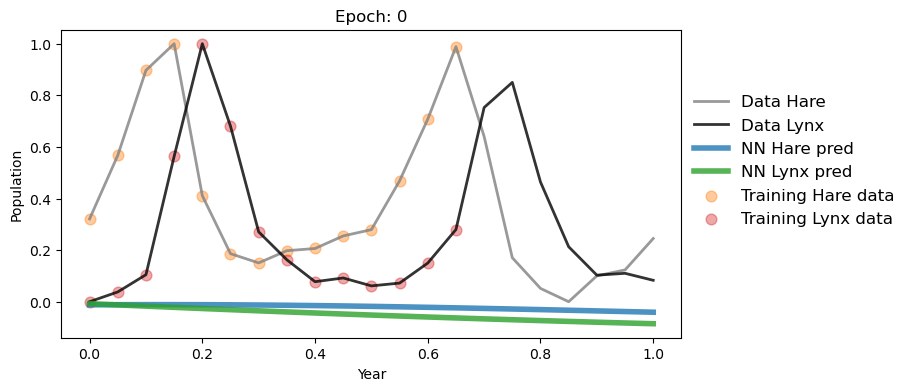

Epoch 0, Loss: 0.3116


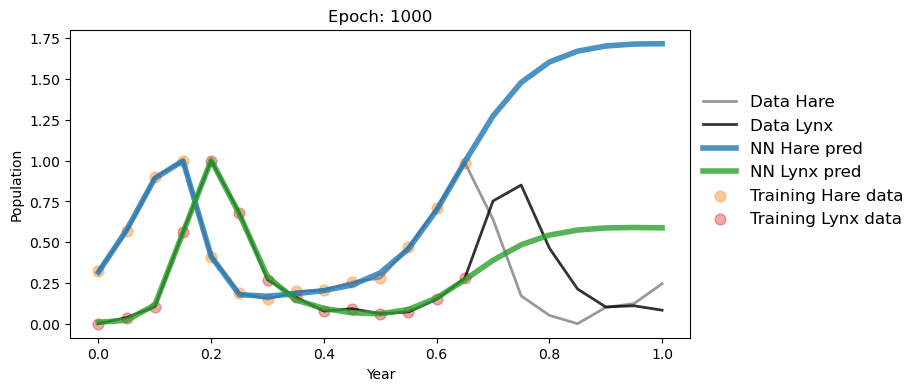

Epoch 1000, Loss: 0.0002


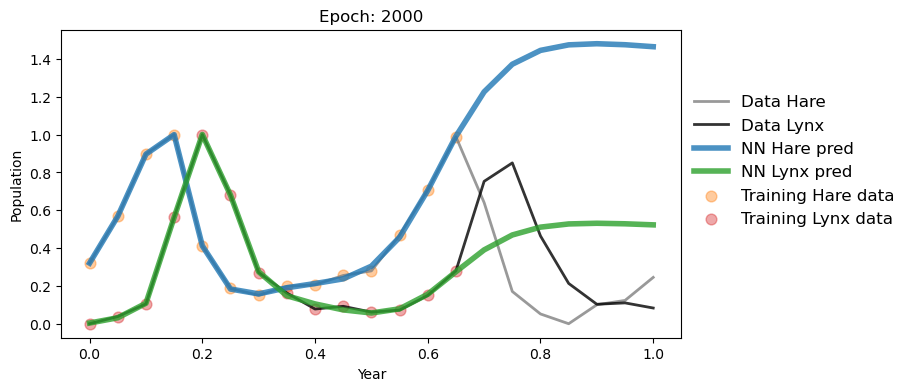

Epoch 2000, Loss: 0.0001


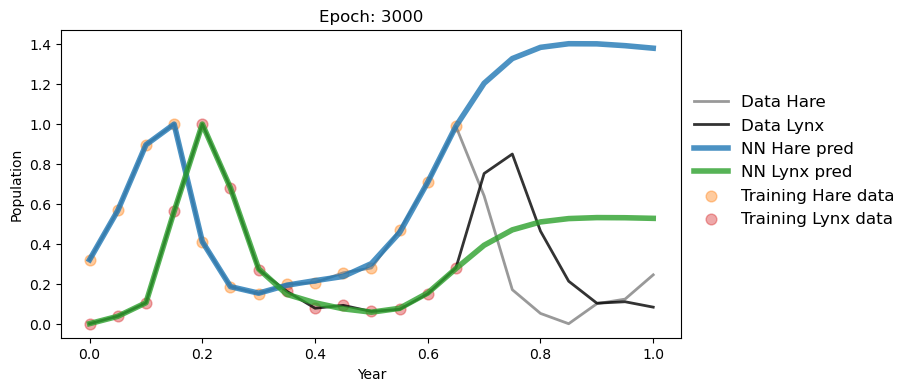

Epoch 3000, Loss: 0.0001


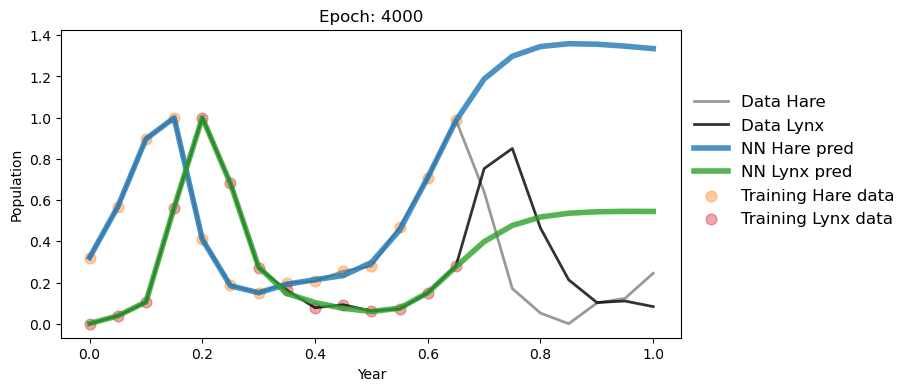

Epoch 4000, Loss: 0.0001


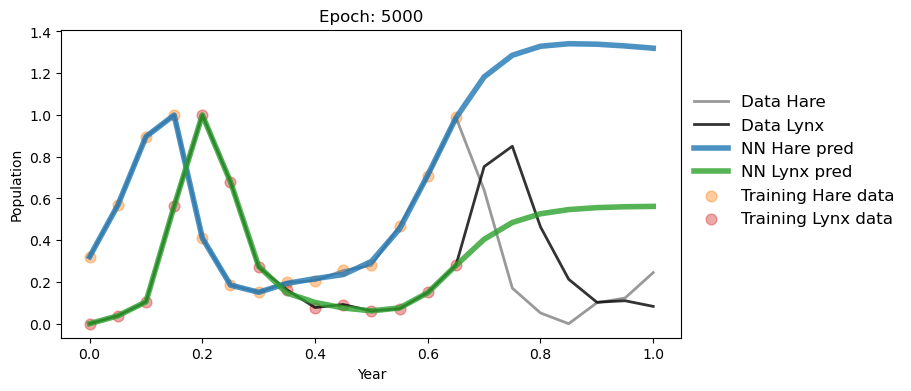

Epoch 5000, Loss: 0.0001


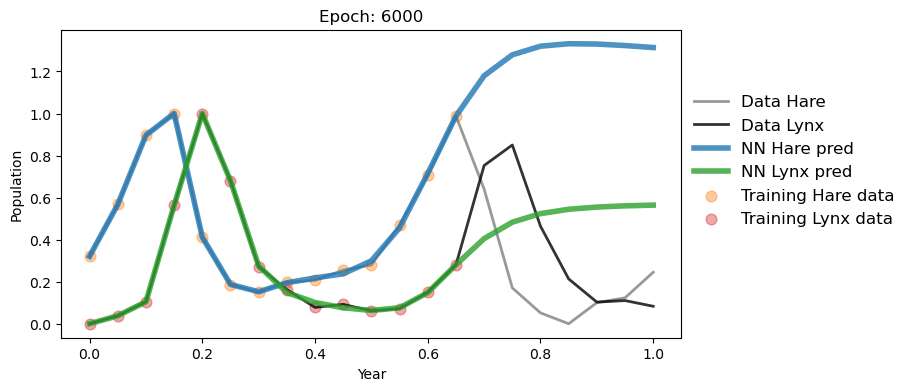

Epoch 6000, Loss: 0.0001


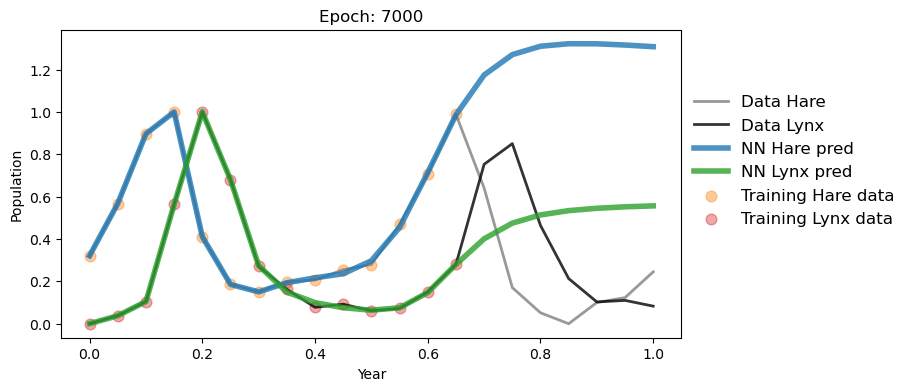

Epoch 7000, Loss: 0.0001


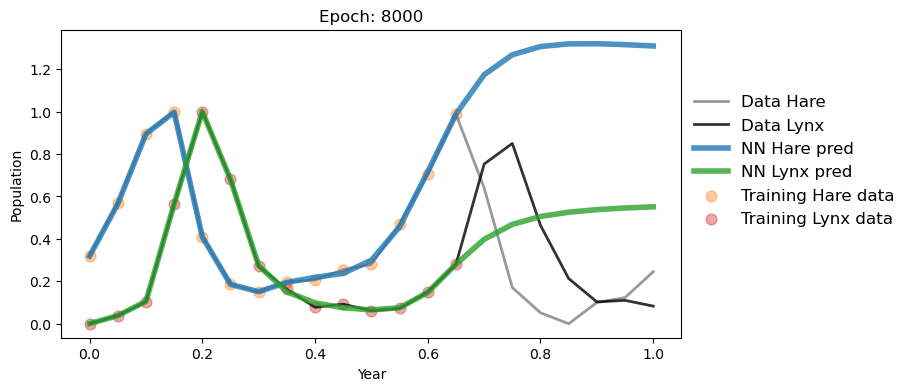

Epoch 8000, Loss: 0.0001


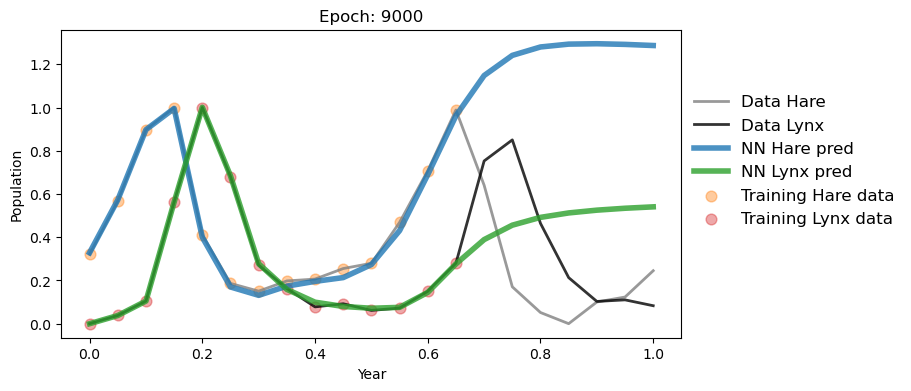

Epoch 9000, Loss: 0.0002


In [54]:
#Training the model for data set 2

model = PopNet(neurons=64,M=4,activation=nn.Tanh())
criterion = nn.MSELoss()
optimizer = tc.optim.Adam(model.parameters(), lr=1*1e-3)

epochs = 10000

for epoch in range(epochs):
    model.train()

    pred = model(tR2_tr)
    loss = criterion(pred, tc.cat([xR2_tr, yR2_tr], dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        testing = model(t_real_2)
        pred_x = testing[:,0]
        pred_y = testing[:,1]
        plot_result(t_real_2 ,x_real_2 ,y_real_2 ,pred_x.detach(),pred_y.detach(),tR2_tr, xR2_tr,yR2_tr, epoch)
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")